In [279]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

In [280]:
doctors = pd.read_csv('/content/doctors_eda_result.txt')

In [281]:
del doctors['Unnamed: 0']

# 1.Влияние опыта работы на цену.

H0: Средняя цена приема не зависит от категории опыта работы.

H1: Существуют статистически значимые различия в средней цене приема между группами врачей с разным опытом работы.

In [282]:
for_hypotheses = doctors.copy()

In [283]:
def exp_group(x):
    if pd.isna(x):
        return 'No value'
    elif x <= 3: return "0–3"
    elif x <= 5: return "4–5"
    elif x <= 7: return "6–7"
    elif x <= 10: return "8–10"
    elif x <= 20: return "11–20"
    else: return "20+"

for_hypotheses["exp_group"] = for_hypotheses["experience"].apply(exp_group)

In [284]:
df = for_hypotheses[for_hypotheses["exp_group"] != "No value"].copy()

In [285]:
df = df[['experience','price','exp_group']].dropna()

In [286]:
df.shape

(4998, 3)

In [287]:
df["exp_group"].value_counts().sort_index()

,count
exp_group,
0–3,71
11–20,1421
20+,2663
4–5,219
6–7,284
8–10,340


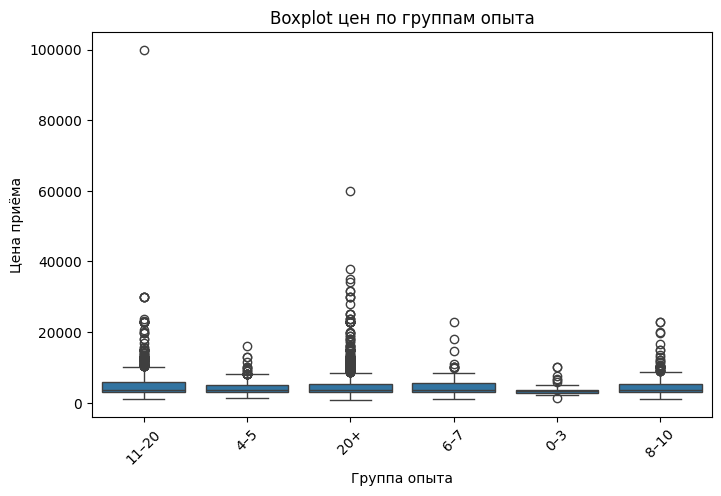

In [288]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="exp_group",y="price")
plt.title("Boxplot цен по группам опыта")
plt.xlabel("Группа опыта")
plt.ylabel("Цена приёма")
plt.xticks(rotation=45)
plt.show()

<Figure size 1200x800 with 0 Axes>

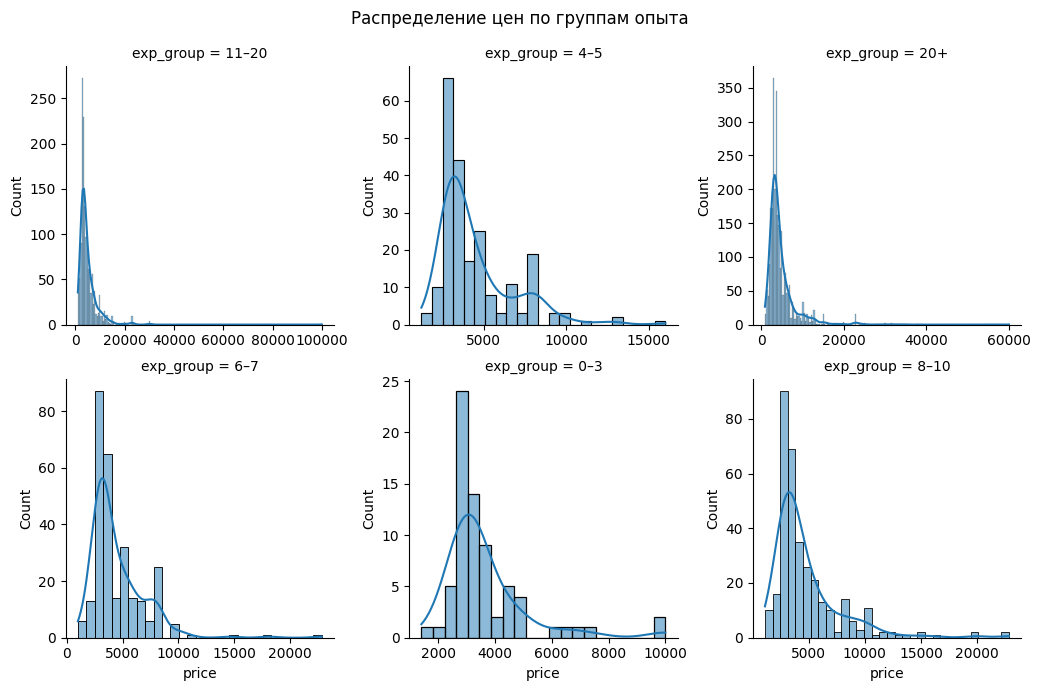

In [289]:
plt.figure(figsize=(12, 8))
g = sns.FacetGrid(df, col="exp_group", col_wrap=3, height=3.5, sharex=False, sharey=False)
g.map(sns.histplot, "price", kde=True)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Распределение цен по группам опыта")

plt.show()

In [290]:
groups = sorted(df["exp_group"].unique())
data_groups = [df[df["exp_group"] == g]["price"].dropna() for g in groups]

levene_stat, levene_p = stats.levene(*data_groups, center='median')

print(f"Levene statistic = {levene_stat:.4f}, p-value = {levene_p:.6f}")

Levene statistic = 3.7906, p-value = 0.001987


статистически значимые различия дисперсий стоимости приема между группами врачей, различающихся по опыту работы

Критерии выбора теста:

6 независимых групп

количественная переменная

данные не нормальны

разные размеры групп (от 71 до 2663)

неоднородность дисперсий

Используем тест Краскела-Уоллиса

In [291]:
from scipy.stats import kruskal
stat, p = kruskal(*data_groups)
print(f"Statistic: {stat:.3f}, p-value: {p:.5f}")

Statistic: 13.132, p-value: 0.02217


средняя цена приёма статистически различается между группами врачей с разным опытом работы, но посмотрим подробнее на группы

Критерии выбора:

Тип данных: Количественные переменные (цены в рублях)

Зависимость выборок: Независимые (разные врачи могут быть только в одной категории опыта)

Количество групп: 2

Распределение: ненормальное

Используем U-критерий Манна-Уитни

Поскольку сравнение рейтинга между группами опыта включало множественные парные сравнения, для контроля ошибки первого рода была применена коррекция Бонферрони.
Это позволило снизить риск ложноположительных выводов и интерпретировать результаты с учётом более строгого уровня значимости.

https://clck.ru/3QsQVp

https://numiqo.com/tutorial/mann-whitney-u-test

In [292]:
from scipy.stats import mannwhitneyu
import itertools

groups = df["exp_group"].unique()
pairs = list(itertools.combinations(groups, 2))

results = []

alpha = 0.05
k = len(pairs)  # number of comparisons
alpha_corrected = alpha / k  # Bonferroni correction

for g1, g2 in pairs:
    data1 = df.loc[df.exp_group == g1, "price"].dropna()
    data2 = df.loc[df.exp_group == g2, "price"].dropna()

    stat, p = mannwhitneyu(data1, data2, alternative="two-sided")

    results.append({
        "group1": g1,
        "group2": g2,
        "U_statistic": stat,
        "p_value_raw": p,
        "p_value_corrected": p * k,
        "significant_after_correction": p * k < alpha
    })

posthoc_df = pd.DataFrame(results)
posthoc_df

,group1,group2,U_statistic,p_value_raw,p_value_corrected,significant_after_correction
0,11–20,4–5,158085.0,0.703196,10.547942,False
1,11–20,20+,1943704.5,0.150088,2.251324,False
2,11–20,6–7,205071.0,0.664108,9.961622,False
3,11–20,0–3,62587.5,0.000609,0.009131,True
4,11–20,8–10,246599.5,0.550370,8.255551,False
5,4–5,20+,294789.5,0.787461,11.811922,False
6,4–5,6–7,31216.0,0.942028,14.130418,False
7,4–5,0–3,9670.0,0.002022,0.030331,True
8,4–5,8–10,37411.5,0.922631,13.839463,False
9,20+,6–7,373448.0,0.730306,10.954595,False


In [293]:
#во всех случаях значимые различия связаны с группой 0-3

проведем односторонние тесты с группой 0-3

In [294]:
base_group = df[df["exp_group"] == "0–3"]["price"].dropna()
groups_to_compare = ["4–5", "6–7", "8–10", "11–20", "20+"]

results = []

for g in groups_to_compare:
    grp = df[df["exp_group"] == g]["price"].dropna()
    stat, p = mannwhitneyu(grp, base_group, alternative="greater")

    results.append({
        "group": g,
        "U_statistic": stat,
        "p_value_one_sided": p
    })

one_sided_df = pd.DataFrame(results)
print(one_sided_df)

   group  U_statistic  p_value_one_sided
0    4–5       9670.0           0.001011
1    6–7      12519.0           0.000813
2   8–10      14712.5           0.001849
3  11–20      62587.5           0.000304
4    20+     115535.0           0.000688


цены у других групп в сравнении с 0-3 выше

По результатам непараметрического критерия Краскела–Уоллиса мы увидели, что стоимость приёма зависит от категории опыта врача (H = 13.132, p = 0.022).

Анализ Mann–Whitney U с коррекцией Бонферрони показал, что статистически значимые различия наблюдаются исключительно между группой врачей с минимальным опытом (0–3 года) и всеми остальными группами (4–5, 6–7, 11–20, 20+).

//////

Между группами (без группы 0-3 года) значимых различий в цене не выявлено.

Таким образом, рост стоимости приёма связан главным образом с переходом от категории «0–3 года» к более опытным специалистам, дальнейшее увеличение опыта не приводит к значимому росту цены.

# 2.Влияние опыта работы на рейтинг (общий и по платформам).
H0: Средний рейтинг врача не зависит от его опыта работы.

H1: Существуют статистически значимые различия в среднем рейтинге между группами врачей с разным опытом работы.

## по платформам

### сбер

In [295]:
df = for_hypotheses[for_hypotheses["exp_group"] != "No value"].copy()

In [296]:
df_sber = df[df["doctor_source"]=="SberHealth"][['rating_sber','doctor_source','exp_group']].copy()
df_prodoctorov =df[df["doctor_source"]=="ProDoctorov"][['rating_prod','doctor_source','exp_group']].copy()

In [297]:
df_sber.dropna(subset=['rating_sber'])
df_prodoctorov.dropna(subset=['rating_prod'])

,rating_prod,doctor_source,exp_group
8,2.1,ProDoctorov,4–5
9,3.1,ProDoctorov,20+
12,2.8,ProDoctorov,20+
13,2.1,ProDoctorov,20+
15,0.0,ProDoctorov,20+
...,...,...,...
490,4.8,ProDoctorov,20+
498,4.2,ProDoctorov,20+
499,3.2,ProDoctorov,20+
500,4.2,ProDoctorov,20+


<Figure size 1200x800 with 0 Axes>

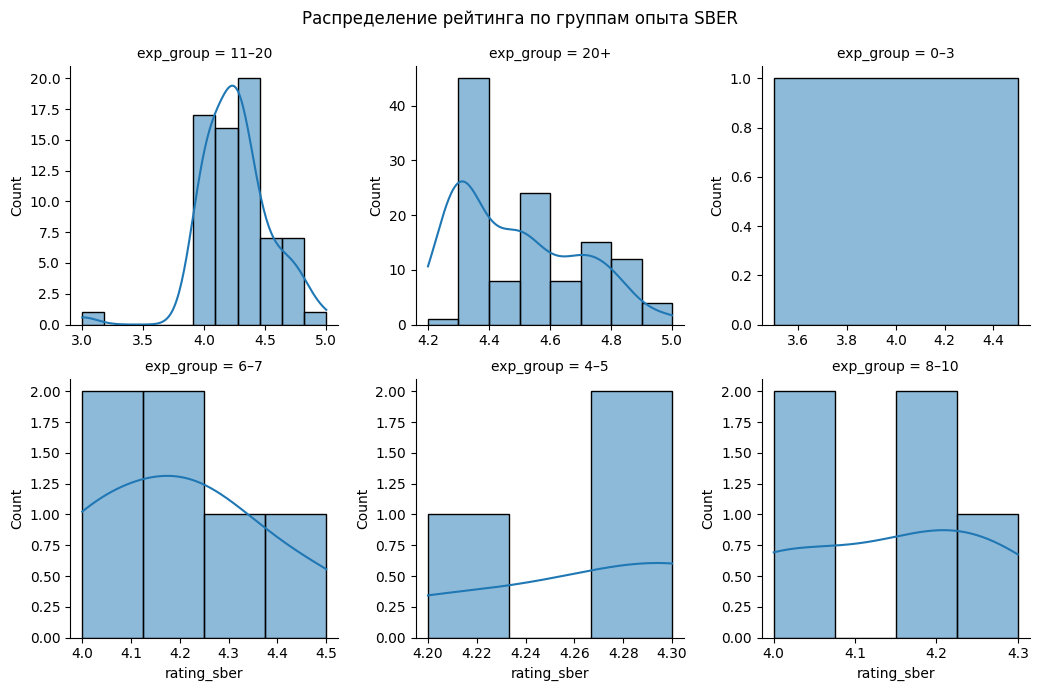

In [298]:
plt.figure(figsize=(12, 8))
g = sns.FacetGrid(df_sber, col="exp_group", col_wrap=3, height=3.5, sharex=False, sharey=False)
g.map(sns.histplot, "rating_sber", kde=True)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Распределение рейтинга по группам опыта SBER")

plt.show()

In [299]:
exp_order = ["0–3","4–5","6–7","8–10","11–20","20+"]
groups = sorted(df_sber["exp_group"].unique(), key=lambda x: exp_order.index(x))
data_groups = [df_sber[df_sber["exp_group"] == g]["rating_sber"].dropna() for g in groups]

levene_stat, levene_p = stats.levene(*data_groups, center='median')
print(f"Levene statistic = {levene_stat:.4f}, p-value = {levene_p:.6f}")

Levene statistic = 1.7739, p-value = 0.119898


In [300]:
stat, p = kruskal(*data_groups)
print(f"SberHealth — Kruskal-Wallis: statistic = {stat:.3f}, p = {p:.5f}")

SberHealth — Kruskal-Wallis: statistic = 55.952, p = 0.00000


различия есть, проведем подробный анализ

In [301]:
results = []
for i in range(len(groups)):
    for j in range(i+1, len(groups)):
        g_high = groups[j]
        g_low = groups[i]

        data_high = df_sber[df_sber["exp_group"]==g_high]["rating_sber"].dropna()
        data_low = df_sber[df_sber["exp_group"]==g_low]["rating_sber"].dropna()

        U, p_one_sided = mannwhitneyu(data_high, data_low, alternative='greater')

        n1, n2 = len(data_high), len(data_low)
        mean_U = n1 * n2 / 2
        std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
        z = (U - mean_U) / std_U
        r = z / np.sqrt(n1 + n2)

        results.append({
            "more_experienced": g_high,
            "less_experienced": g_low,
            "U_statistic": U,
            "p_one_sided": p_one_sided,
            "effect_size_r": r
        })

df_posthoc_sber = pd.DataFrame(results)
df_posthoc_sber

,more_experienced,less_experienced,U_statistic,p_one_sided,effect_size_r
0,4–5,0–3,3.0,1.728893e-01,0.670820
1,6–7,0–3,5.0,2.159615e-01,0.377964
2,8–10,0–3,4.0,2.635446e-01,0.358569
3,11–20,0–3,59.5,1.082863e-01,0.147886
4,20+,0–3,117.0,3.892057e-02,0.158103
5,6–7,4–5,6.0,8.262934e-01,-0.258199
6,8–10,4–5,3.0,9.426737e-01,-0.474342
7,11–20,4–5,94.0,6.130691e-01,-0.031550
8,20+,4–5,303.5,1.306612e-02,0.196410
9,8–10,6–7,12.5,7.176579e-01,-0.137620


p_one_sided > 0.05 у большинства пар => различия в рейтинге не статистически значимы

Значимые различия (p < 0.05) наблюдаются только для более опытных врачей:

20+ vs 0-3 (p = 0.0389) => опытные врачи выше

20+ vs 4-5 (p = 0.0131)

20+ vs 6-7 (p = 0.008)

20+ vs 8–10 (p = 0.00018)

20+ vs 11-20 (p= 1.77e-10)

Эффект размера r:

Для значимых различий r ≈ 0.1 и 0.45 => умеренный эффект

H0 отклоняем только для группы врачей 20+:

Рейтинг зависит от опыта только для старших, очень опытных врачей (20+ лет)

Для младших и средних групп различия не значимы, то есть рейтинг не зависит от опыта


### про докторов

<Figure size 1200x800 with 0 Axes>

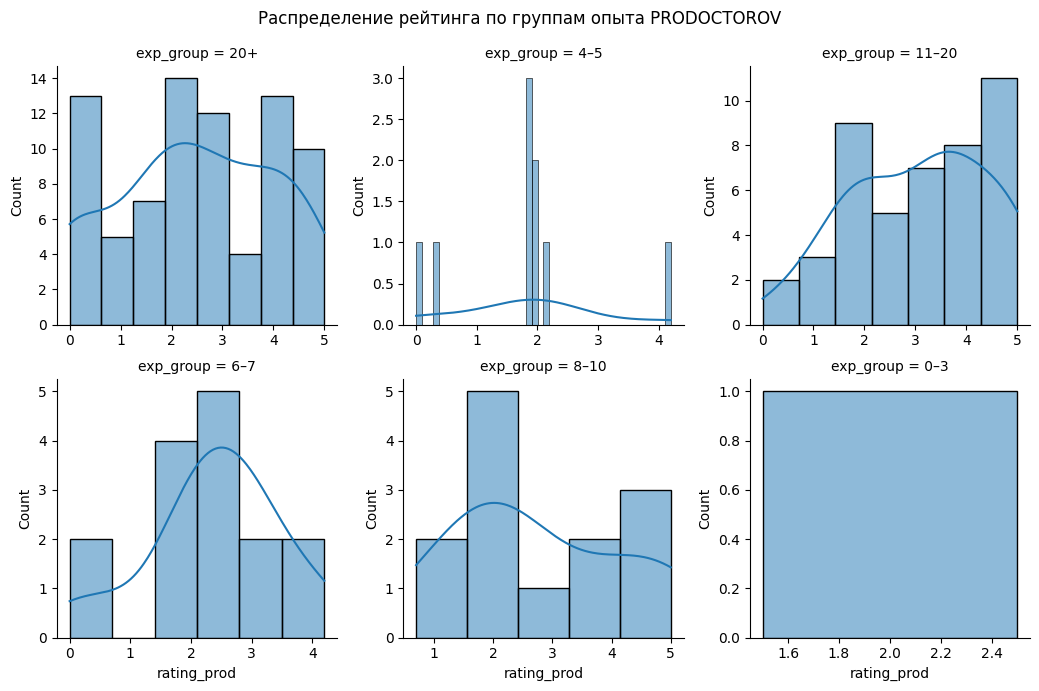

In [302]:
plt.figure(figsize=(12, 8))
g = sns.FacetGrid(df_prodoctorov, col="exp_group", col_wrap=3, height=3.5, sharex=False, sharey=False)
g.map(sns.histplot, "rating_prod", kde=True)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Распределение рейтинга по группам опыта PRODOCTOROV")

plt.show()

In [303]:
exp_order = ["0–3","4–5","6–7","8–10","11–20","20+"]
groups = sorted(df_prodoctorov["exp_group"].unique(), key=lambda x: exp_order.index(x))
data_groups = [df_prodoctorov[df_prodoctorov["exp_group"] == g]["rating_prod"].dropna() for g in groups]

levene_stat, levene_p = stats.levene(*data_groups, center='median')
print(f"Levene statistic = {levene_stat:.4f}, p-value = {levene_p:.6f}")

Levene statistic = 2.0928, p-value = 0.069161


In [304]:
stat, p = kruskal(*data_groups)
print(f"SberHealth — Kruskal-Wallis: statistic = {stat:.3f}, p = {p:.5f}")

SberHealth — Kruskal-Wallis: statistic = 8.113, p = 0.15012


p > 0.05 => различия в рейтингах между группами опыта на платформе незначимы.

## работа с двумя платформами

(Взят наш рейтинг для эксперимента, чтобы сравнить в общем по рейтингу и опыту с двух платформ. А выше сравнение по платформам по оригинальным рейтингам, как предполагала гипотеза)

In [305]:
df = for_hypotheses[for_hypotheses["exp_group"] != "No value"].copy()
df = df[['experience','rating','exp_group','doctor_source']].dropna()

In [306]:
df["exp_group"].value_counts().sort_index()

,count
exp_group,
0–3,363
11–20,4368
20+,8350
4–5,1071
6–7,1277
8–10,1361


<Figure size 1200x800 with 0 Axes>

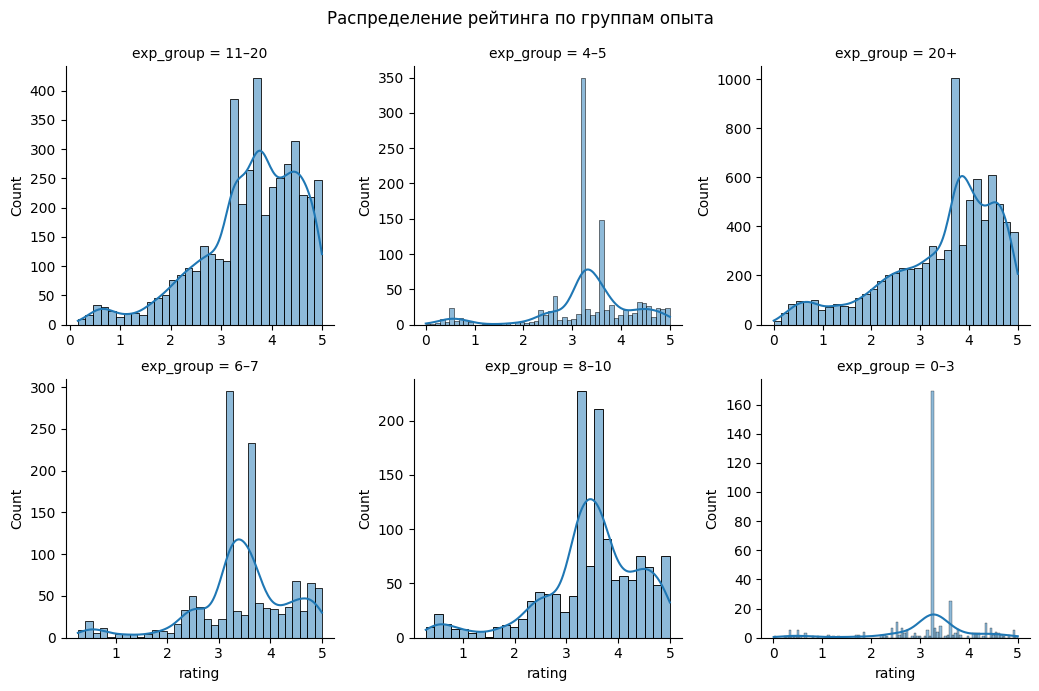

In [307]:
plt.figure(figsize=(12, 8))
g = sns.FacetGrid(df, col="exp_group", col_wrap=3, height=3.5, sharex=False, sharey=False)
g.map(sns.histplot, "rating", kde=True)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Распределение рейтинга по группам опыта")

plt.show()

In [308]:
groups = sorted(df["exp_group"].unique())
data_groups = [df[df["exp_group"] == g]["rating"].dropna() for g in groups]

levene_stat, levene_p = stats.levene(*data_groups, center='median')

print(f"Levene statistic = {levene_stat:.4f}, p-value = {levene_p:.6f}")

Levene statistic = 53.0996, p-value = 0.000000


статистически значимые различия дисперсий рейтинга между группами врачей, различающихся по опыту работы

Критерии выбора теста:

6 независимых групп

количественная переменная

данные не нормальны

разные размеры групп (от 363 до 8350)

неоднородность дисперсий

Используем тест Краскела-Уоллиса

In [309]:
kw_stat, kw_p = kruskal(*data_groups)
print(f"Kruskal-Wallis: statistic={kw_stat:.3f}, p={kw_p:.6f}")

Kruskal-Wallis: statistic=191.023, p=0.000000


средний рейтинг статистически различается между группами врачей с разным опытом работы, но посмотрим подробнее на группы

Критерии выбора:

Тип данных: Количественные переменные (рейтинг)

Зависимость выборок: Независимые (разные врачи могут быть только в одной категории опыта)

Количество групп: 2

Распределение: ненормальное

Используем U-критерий Манна-Уитни

In [310]:
pairs = list(itertools.combinations(groups, 2))
results = []
for a, b in pairs:
    g1 = df[df["exp_group"]==a]["rating"].dropna()
    g2 = df[df["exp_group"]==b]["rating"].dropna()
    stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
    results.append([a, b, stat, p])

posthoc_all = pd.DataFrame(results, columns=["group1","group2","U_statistic","p_raw"])
posthoc_all["p_corrected"] = posthoc_all["p_raw"] * len(posthoc_all)
posthoc_all["significant"] = posthoc_all["p_corrected"] < 0.05

posthoc_all

,group1,group2,U_statistic,p_raw,p_corrected,significant
0,0–3,11–20,546607.0,6.899160e-23,1.034874e-21,True
1,0–3,20+,1127396.0,1.276865e-16,1.915297e-15,True
2,0–3,4–5,166836.5,3.604771e-05,5.407157e-04,True
3,0–3,6–7,183565.0,9.363932e-10,1.404590e-08,True
4,0–3,8–10,185767.0,2.689158e-13,4.033736e-12,True
5,11–20,20+,18800988.5,4.076137e-03,6.114205e-02,False
6,11–20,4–5,2781671.5,6.737360e-22,1.010604e-20,True
7,11–20,6–7,3118931.5,1.162641e-10,1.743961e-09,True
8,11–20,8–10,3240618.0,4.766203e-07,7.149305e-06,True
9,20+,4–5,5133038.5,2.835309e-15,4.252964e-14,True


есть статистически значимый эффект

проверим односторонние гипотезы

In [311]:
exp_order = ["0–3", "4–5", "6–7", "8–10", "11–20", "20+"]
significant_pairs = posthoc_all[posthoc_all["significant"] == True]
effect_size_results = []

for i, row in significant_pairs.iterrows():
    g1_name, g2_name = row["group1"], row["group2"]
    if exp_order.index(g1_name) > exp_order.index(g2_name):
        g_high = g1_name
        g_low = g2_name
    else:
        g_high = g2_name
        g_low = g1_name

    g1 = df[df["exp_group"]==g_high]["rating"].dropna()
    g2 = df[df["exp_group"]==g_low]["rating"].dropna()

    U, p_one_sided = mannwhitneyu(g1, g2, alternative='greater')

    # Эффект размера r = Z / sqrt(N)
    n1, n2 = len(g1), len(g2)
    mean_U = n1 * n2 / 2
    std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z = (U - mean_U) / std_U
    r = z / np.sqrt(n1 + n2)

    effect_size_results.append({
        "more_experienced": g_high,
        "less_experienced": g_low,
        "U_statistic": U,
        "p_one_sided": p_one_sided,
        "effect_size_r": r
    })

effect_size_df = pd.DataFrame(effect_size_results)
effect_size_df

,more_experienced,less_experienced,U_statistic,p_one_sided,effect_size_r
0,11–20,0–3,1038977.0,3.449580e-23,0.143139
1,20+,0–3,1903654.0,6.384323e-17,0.088629
2,4–5,0–3,221936.5,1.802386e-05,0.106700
3,6–7,0–3,279986.0,4.681966e-10,0.149523
4,8–10,0–3,308276.0,1.344579e-13,0.175058
5,11–20,4–5,2781671.5,3.368680e-22,0.130321
6,11–20,6–7,3118931.5,5.813204e-11,0.085727
7,11–20,8–10,3240618.0,2.383102e-07,0.066505
8,20+,4–5,5133038.5,1.417655e-15,0.081346
9,20+,6–7,5766432.5,1.276881e-06,0.047928


r ≈ 0.2 — маленький эффект

r ≈ 0.5 — средний

r ≈ 0.8 — большой

**0–3 года** опыта vs все остальные группы:

Более опытные группы (4–5, 6–7, 8–10, 11–20, 20+) имеют значимо выше рейтинг, чем 0–3

Эффект размера r = 0.088–0.175 =>малый эффект


**11–20 vs 4–5:** r = 0.13, p < 0.05 → опытная группа выше

**11–20 vs 6–7:** r = 0.086 => рейтинг выше, но эффект меньше

**11–20 vs 8–10:** r = 0.066 => рейтинг выше, эффект небольшой

**20+ vs 4–5:** r = 0.081, 20+ vs 6–7: r = 0.048, 20+ vs 8–10: r = 0.035: различия есть, но слабые

**4–5 vs 6–7, 4–5 vs 8–10:** рейтинг растет с опытом, p < 0.05, r = 0.06 и 0.09 => слабый, но значимый эффект

***вывод: у врачей с большим опытом(чем 0-3) наблюдается значимый, но очень слабый эффект в рейтинге***

В общем значимых статистически различий не обнаружено

# 3.Распределение опыта работы на разных платформах.
H0: Распределение врачей по категориям опыта работы одинаково на обеих платформах.

H1: На платформе СберЗдоровья врачи в среднем имеют больше опыта работы



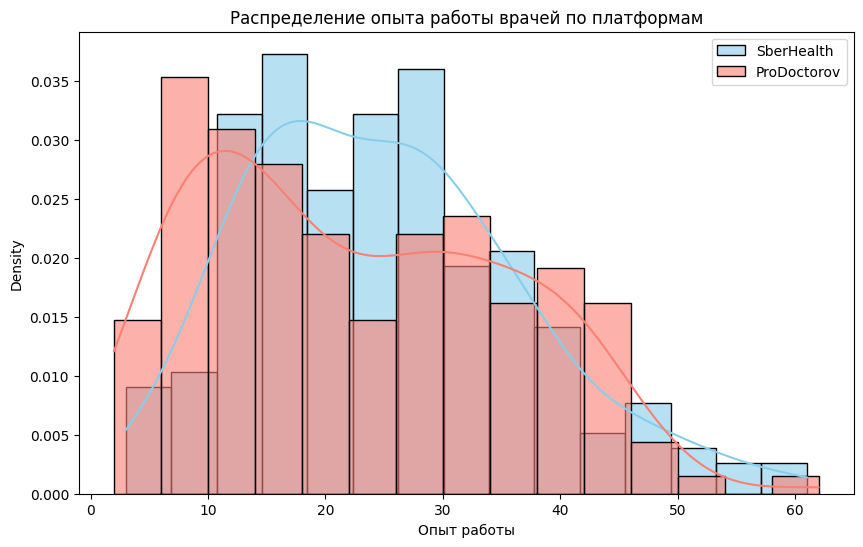

In [312]:
sber = df[df['doctor_source']=='SberHealth']['experience']
prodoctorov = df[df['doctor_source']=='ProDoctorov']['experience']

plt.figure(figsize=(10,6))
sns.histplot(sber, bins=15, color='skyblue', label='SberHealth', kde=True, stat="density", alpha=0.6)
sns.histplot(prodoctorov, bins=15, color='salmon', label='ProDoctorov', kde=True, stat="density", alpha=0.6)

plt.title("Распределение опыта работы врачей по платформам")
plt.xlabel("Опыт работы")
plt.legend()
plt.show()

In [313]:
sber = df[df['doctor_source']=='SberHealth']['experience'].dropna()
prodoctorov = df[df['doctor_source']=='ProDoctorov']['experience'].dropna()

levene_stat, levene_p = stats.levene(sber, prodoctorov, center='median')
print(f"{levene_stat:.4f}, p-value = {levene_p:.6f}")

6.0172, p-value = 0.014629


Критерии выбора:

Тип данных: Количественные переменные (опыт в годах)

Зависимость выборок: Независимые (разные врачи на разных платформах)

Количество групп: 2

Распределение: ненормальное

Используем U-критерий Манна-Уитни

In [314]:
sber = df[df['doctor_source']=='SberHealth']['experience'].dropna()
prodoctorov = df[df['doctor_source']=='ProDoctorov']['experience'].dropna()

U_stat, p_value = mannwhitneyu(sber, prodoctorov, alternative='greater')
print(f"Mann-Whitney U test: U = {U_stat:.3f}, p = {p_value:.5f}")

Mann-Whitney U test: U = 19161.500, p = 0.02180


In [315]:
df_exp = df[['experience','doctor_source']].dropna()
mean_experience = df_exp.groupby('doctor_source')['experience'].mean().reset_index()
mean_experience.rename(columns={'experience': 'mean_experience'}, inplace=True)

mean_experience

,doctor_source,mean_experience
0,ProDoctorov,22.517647
1,SberHealth,24.975124
2,Обе платформы,21.648395


На платформе СберЗдоровья врачи в среднем имеют больше опыта работы

In [316]:
experience_sber = sber.values
experience_prod = prodoctorov.values

np.random.seed(42)
n_bootstrap = 1500
bootstrap_diffs = []

for i in range(n_bootstrap):
    sample_sber = np.random.choice(experience_sber, size=len(experience_sber), replace=True)
    sample_prod = np.random.choice(experience_prod, size=len(experience_prod), replace=True)
    bootstrap_diffs.append(np.median(sample_sber) - np.median(sample_prod))

ci_lower = np.percentile(bootstrap_diffs, 2.5)
ci_upper = np.percentile(bootstrap_diffs, 97.5)
median_diff = np.median(experience_sber) - np.median(experience_prod)

print(f'Разница медиан: {median_diff:.1f} лет')
print(f'95% доверительный интервал для разницы медиан: от {ci_lower:.1f} до {ci_upper:.1f} лет')

Разница медиан: 3.0 лет
95% доверительный интервал для разницы медиан: от -1.0 до 7.5 лет


В среднем врачи на SberHealth имеют на 3 года больше опыта, чем на ProDoctorov

Однако доверительный интервал широкий и включает ноль, поэтому разница может быть случайной

# 4.Рейтинг на СберЗдоровье выше.
H0: Средний рейтинг врачей на СберЗдоровье равен среднему рейтингу врачей на ProDoctorov

H1: Средний рейтинг врачей на СберЗдоровье статистически значимо выше, чем на ProDoctorov

In [317]:
df = for_hypotheses[['rating_prod','rating_sber','doctor_source']]

In [318]:
df

,rating_prod,rating_sber,doctor_source
0,NaN,NaN,ProDoctorov
1,NaN,NaN,ProDoctorov
2,NaN,4.5,SberHealth
3,NaN,4.0,SberHealth
4,NaN,4.3,SberHealth
...,...,...,...
38860,0.0,NaN,ProDoctorov
38861,NaN,4.7,Обе платформы
38862,1.4,4.0,Обе платформы
38863,4.0,4.3,Обе платформы


In [319]:
sber_rating = df[df['doctor_source']=='SberHealth']['rating_sber'].dropna()
prodoctorov_rating = df[df['doctor_source']=='ProDoctorov']['rating_prod'].dropna()

In [320]:
levene_stat, levene_p = stats.levene(sber_rating, prodoctorov_rating, center='median')
print(f"Levene statistic = {levene_stat:.4f}, p-value = {levene_p:.6f}")

Levene statistic = 22201.8339, p-value = 0.000000


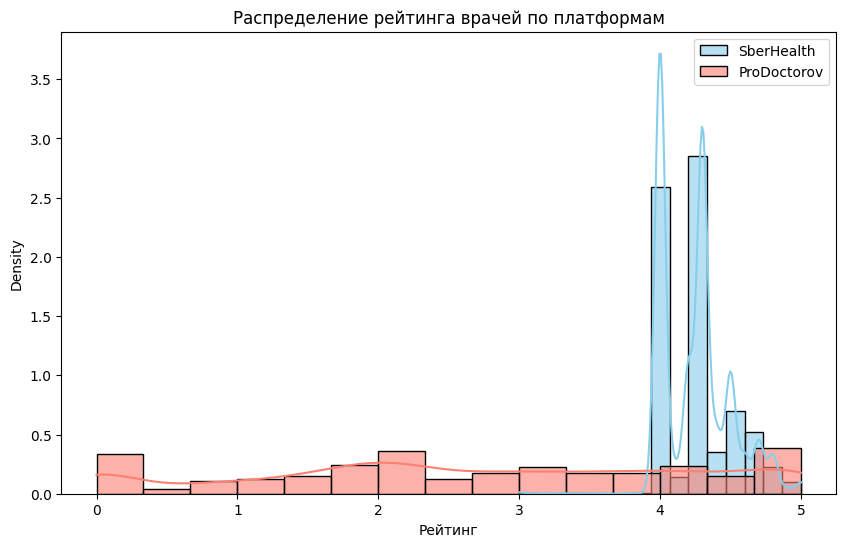

In [321]:
plt.figure(figsize=(10,6))
sns.histplot(sber_rating, bins=15, color='skyblue', label='SberHealth', kde=True, stat="density", alpha=0.6)
sns.histplot(prodoctorov_rating, bins=15, color='salmon', label='ProDoctorov', kde=True, stat="density", alpha=0.6)
plt.title("Распределение рейтинга врачей по платформам")
plt.xlabel("Рейтинг")
plt.legend()
plt.show()

Критерии выбора:

Тип данных: Количественные переменные (рейтинг)

Зависимость выборок: Независимые (разные врачи на разных платформах)

Количество групп: 2

Распределение: ненормальное

Используем U-критерий Манна-Уитни

In [322]:
U_stat, p_one_sided = mannwhitneyu(sber_rating, prodoctorov_rating, alternative='greater')
print(f"Mann-Whitney U test: U = {U_stat:.3f}, p = {p_one_sided:.5f}")

Mann-Whitney U test: U = 50297184.500, p = 0.00000


In [323]:
n1, n2 = len(sber_rating), len(prodoctorov_rating)
mean_U = n1 * n2 / 2
std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
z = (U_stat - mean_U) / std_U
r = z / np.sqrt(n1 + n2)

print(f"Effect size r = {r:.3f}")

Effect size r = 0.465


достаточно большой эффект

In [324]:
np.random.seed(42)
n_bootstrap = 1500
bootstrap_diffs = []

for i in range(n_bootstrap):
    sample_sber = np.random.choice(sber_rating, size=len(sber_rating), replace=True)
    sample_prod = np.random.choice(prodoctorov_rating, size=len(prodoctorov_rating), replace=True)
    bootstrap_diffs.append(np.median(sample_sber) - np.median(sample_prod))

ci_lower = np.percentile(bootstrap_diffs, 2.5)
ci_upper = np.percentile(bootstrap_diffs, 97.5)
median_diff = np.median(sber_rating) - np.median(prodoctorov_rating)

print(f'Разница медиан: {median_diff:.2f} рейтинга')
print(f'95% доверительный интервал для разницы медиан: от {ci_lower:.2f} до {ci_upper:.2f}')

Разница медиан: 1.60 рейтинга
95% доверительный интервал для разницы медиан: от 1.60 до 1.70


Интервал полностью выше 0 => медиана рейтингов на SberHealth статистически значимо выше, чем на ProDoctorov.

Разница в 1.6–1.7 балла по рейтингу — это существенное различие, подтверждающее вывод Mann–Whitney + сильный эффект r = 0.465

Таким образом, гипотеза H1 принимается: рейтинг на SberHealth выше

# 5.Рейтинг одних и тех же врачей выше на СберЗдоровье.
H0: Для врачей, представленных на обеих платформах, разница в рейтингах c разных ресурсов отсутсвует

H1: Для врачей, представленных на обеих платформах, рейтинг на СберЗдоровье статистически значимо выше, чем на ProDoctorov

Ввели новый признак: разница в рейтингах на платформах, тогда

если > 0 значит больше на Сбере,

если < 0 - больше на ПроДокторов

если = 0 - одинаково

In [325]:
both_platforms = doctors[doctors['doctor_source'] == 'Обе платформы']

both_platforms = both_platforms[['name', 'rating_sber', 'rating_prod']].dropna(subset=['rating_sber', 'rating_prod'])

both_platforms['rating_diff'] = both_platforms['rating_sber'] - both_platforms['rating_prod']

In [326]:
both_platforms['rating_diff'].describe()

,rating_diff
count,12303.000000
mean,1.844835
std,1.518211
min,-1.900000
25%,0.600000
50%,1.900000
75%,3.000000
max,5.000000


In [327]:
both_platforms[both_platforms['rating_diff']==0].shape[0]/both_platforms.shape[0]
np.percentile(both_platforms['rating_diff'], 50)

np.float64(1.8999999999999995)

In [328]:
from scipy.stats import pearsonr, spearmanr, kendalltau

corr_pearson, p_value_pearson = pearsonr(both_platforms['rating_sber'], both_platforms['rating_prod'])
print(f"Корреляция Пирсона: {corr_pearson:.4f}")

corr_spearman, p_value_spearman = spearmanr(both_platforms['rating_sber'], both_platforms['rating_prod'])
print(f"Корреляция Спирмена: {corr_spearman:.4f}")

Корреляция Пирсона: 0.1983
Корреляция Спирмена: 0.1799


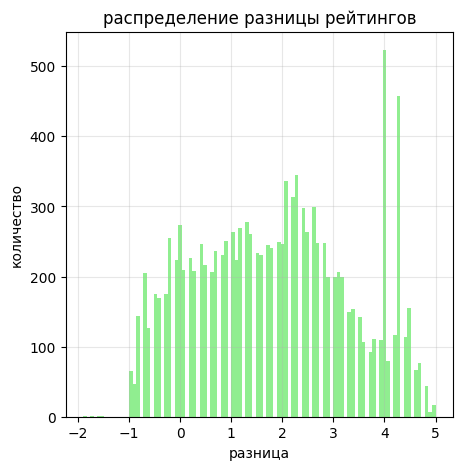

In [329]:
figure = plt.figure(figsize=(5,5))

plt.hist(both_platforms['rating_diff'],color='lightgreen', bins = 100)
plt.title('распределение разницы рейтингов')
plt.xlabel('разница')
plt.ylabel('количество')
plt.grid(alpha=0.3)
plt.show()

Критерии выбора:

Парные наблюдения — одни и те же врачи на двух платформах

Разница рейтингов — количественная переменная

Распределение разницы — ненормально

Используем тест Вилкоксона

In [330]:
res = stats.wilcoxon(both_platforms['rating_sber'], both_platforms['rating_prod'], alternative='greater', method='auto' )
print(f"p-value: {res.pvalue:.10f}")

p-value: 0.0000000000


In [331]:
diff = both_platforms['rating_diff']
n = len(diff) - (diff == 0).sum()
z = res.statistic - (n*(n+1)/4)
z = z / np.sqrt(n*(n+1)*(2*n+1)/24)

effect = z / np.sqrt(len(both_platforms))
print(f'Z-статистика для Вилкоксона: {z:.3f}')
print(f'размер эффекта: {effect:.3f}')

Z-статистика для Вилкоксона: 87.895
размер эффекта: 0.792


оценим точность с помощью вычисления доверительного интервала с помощью бутстрапа

In [332]:
np.random.seed(42)
n_bootstrap = 10000
bootstrap_medians = []

for _ in range(n_bootstrap):
    sample = np.random.choice(diff, size=len(diff), replace=True)
    bootstrap_medians.append(np.mean(sample))

ci_lower = np.percentile(bootstrap_medians, 2.5)
ci_upper = np.percentile(bootstrap_medians, 97.5)
median_diff = np.mean(diff)

print(f'средняя разница цен: {median_diff:.0f}')
print(f'95% доверительный интервал для средней разницы: от {ci_lower:.0f} до {ci_upper:.0f}')

средняя разница цен: 2
95% доверительный интервал для средней разницы: от 2 до 2


Цены на СберЗдоровье статистически значимо выше, подтверждается z статистикой, а также размер эффекта большой 0.792

рассмотрим также без нулевых разниц

In [333]:
nonzero_diff = diff[diff != 0]

print(f'кол-во ненулевых разниц: {len(nonzero_diff)} из {len(diff)} {len(nonzero_diff)/len(diff)*100:.1f}%')
print(f'медиана ненулевых разниц: {np.median(nonzero_diff):.0f}')
print(f'среднее ненулевых разниц: {np.mean(nonzero_diff):.0f}')

np.random.seed(42)
bootstrap_nonzero_medians = []

for _ in range(10000):
    sample = np.random.choice(nonzero_diff, size=len(nonzero_diff), replace=True)
    bootstrap_nonzero_medians.append(np.mean(sample))

ci_lower_nz = np.percentile(bootstrap_nonzero_medians, 2.5)
ci_upper_nz = np.percentile(bootstrap_nonzero_medians, 97.5)


print(f'медианная разница: {np.mean(nonzero_diff):.0f}')
print(f'95% доверительный интервал: от {ci_lower_nz:.0f} до {ci_upper_nz:.0f}')

кол-во ненулевых разниц: 12029 из 12303 97.8%
медиана ненулевых разниц: 2
среднее ненулевых разниц: 2
медианная разница: 2
95% доверительный интервал: от 2 до 2


посмотрим, что происходит если цены все таки разные

средняя разница цен: 2

95% доверительный интервал для средней разницы: от 2 до 2

Разница медиан ~ 2 балла => это большое различие, подтверждающее сильный эффект r = 0.792

Вывод:

гипотеза H0 отклоняется: для врачей, представленных на обеих платформах, рейтинг на SberHealth значительно выше

# 6.Средняя цена на СберЗдоровье выше.


H0: Средняя цена приема врачей на СберЗдоровье равна средней цене на ProDoctorov.

H1: Средняя цена приема врачей на СберЗдоровье статистически значимо выше, чем на ProDoctorov

In [334]:
doctors['doctor_source'].value_counts()

,count
doctor_source,
Обе платформы,18711
SberHealth,13208
ProDoctorov,6946


In [335]:
doctor_p = doctors[doctors['doctor_source']=='ProDoctorov']
doctor_s = doctors[doctors['doctor_source']=='SberHealth']

price_sber = doctor_s['price_sber']
price_prod = doctor_p['price_prod']

price_sber = price_sber.dropna()
price_prod = price_prod.dropna()

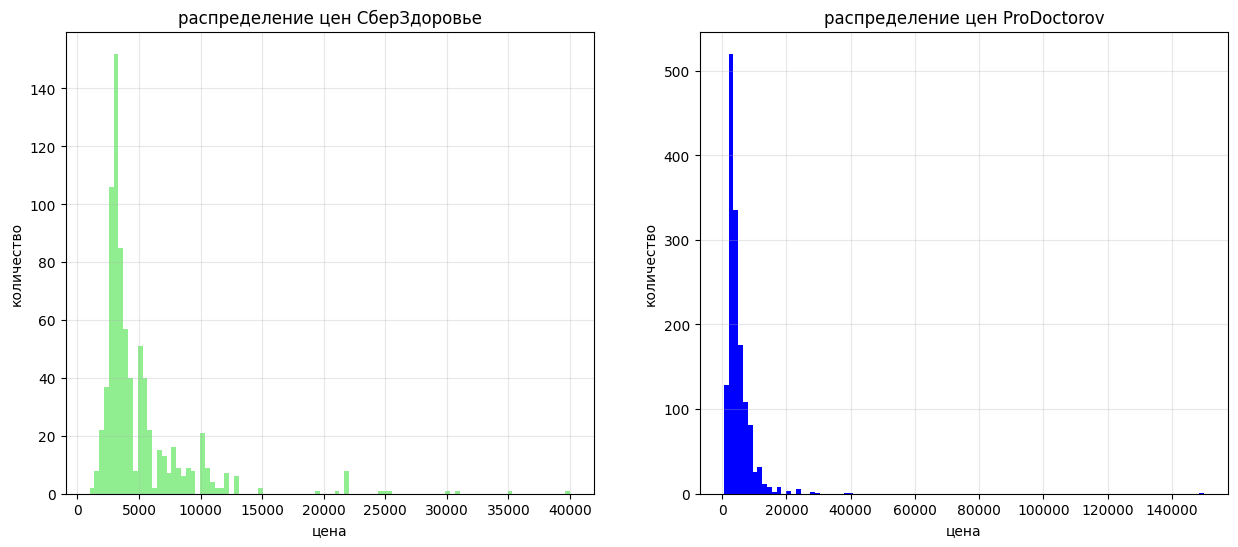

In [336]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(price_sber,color='lightgreen', bins = 100)
axes[0].set_title('распределение цен СберЗдоровье')
axes[0].set_xlabel('цена')
axes[0].set_ylabel('количество')
axes[0].grid(alpha=0.3)

axes[1].hist(price_prod,color='blue', bins = 100)
axes[1].set_title('распределение цен ProDoctorov')
axes[1].set_xlabel('цена')
axes[1].set_ylabel('количество')
axes[1].grid(alpha=0.3)

In [337]:
price_sber_log = np.log(price_sber)
price_prod_log = np.log(price_prod)

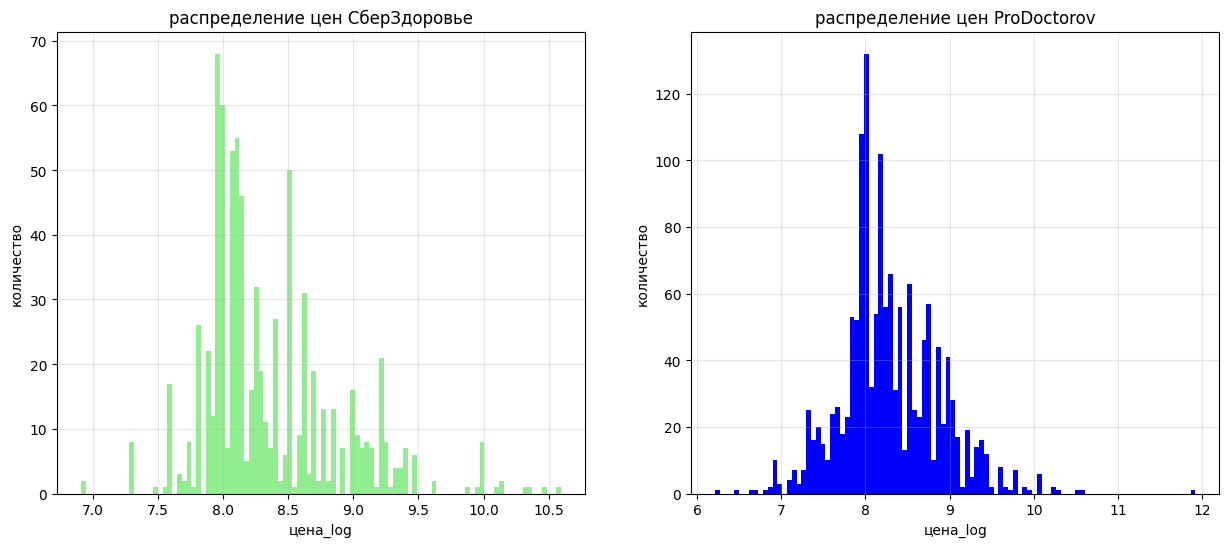

In [338]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(price_sber_log,color='lightgreen', bins = 100)
axes[0].set_title('распределение цен СберЗдоровье')
axes[0].set_xlabel('цена_log')
axes[0].set_ylabel('количество')
axes[0].grid(alpha=0.3)

axes[1].hist(price_prod_log,color='blue', bins = 100)
axes[1].set_title('распределение цен ProDoctorov')
axes[1].set_xlabel('цена_log')
axes[1].set_ylabel('количество')
axes[1].grid(alpha=0.3)
plt.show()

In [339]:
params = stats.norm.fit(price_prod_log)
ks_stat, p_value = stats.kstest(price_prod_log, 'norm', args=params)
print('нормальное',p_value)

params = stats.norm.fit(price_sber_log)
ks_stat, p_value = stats.kstest(price_sber_log, 'norm', args=params)
print('нормальное',p_value)

нормальное 2.6198473785205807e-10
нормальное 5.041785851038992e-15


Критерии выбора:

Тип данных: Количественные переменные (цены в рублях)

Зависимость выборок: Независимые (разные врачи на разных платформах)

Количество групп: 2

Распределение: ненормальное - правосторонняя асимметрия

Размер выборки: > 1000 значений

Используем U-критерий Манна-Уитни

In [340]:
res = stats.mannwhitneyu(price_sber, price_prod, alternative='greater', method= 'auto')
print(f'{res.pvalue:.10f}')

0.0068362401


p-value < 0.05 Значит выборки различия в них статистически значимы

In [341]:
print(np.mean(price_prod), np.mean(price_sber))

4824.081323225362 5021.234394904459


Для проверки односторонней гипотезы вычислим Z статистику и размер эффекта

In [342]:
n1, n2 = len(price_sber), len(price_prod)
U = res.statistic

z_stat = (U - n1 * n2 / 2) / np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
effect_size = z_stat / np.sqrt(n1 + n2)
print(f'Z-статистика: {z_stat:.3f}')
print(f'Размер эффекта: {effect_size:.3f}')

Z-статистика: 2.465
Размер эффекта: 0.052


Положительная Z-статистика (2.465) подтверждает направление

Вывод: Цены на СберЗдоровье действительно выше, чем на ПроДокторов

r = 0.052 — очень малый эффект (по классификации Коэна)

Несмотря на статистическую значимость, практическая значимость минимальна

In [343]:
np.random.seed(42)
n_bootstrap = 1500
bootstrap_diffs = []

for _ in range(n_bootstrap):
    sample_sber = np.random.choice(price_sber, size=len(price_sber), replace=True)
    sample_prod = np.random.choice(price_prod, size=len(price_prod), replace=True)
    bootstrap_diffs.append(np.median(sample_sber) - np.median(sample_prod))

ci_lower = np.percentile(bootstrap_diffs, 2.5)
ci_upper = np.percentile(bootstrap_diffs, 97.5)
median_diff = np.median(price_sber) - np.median(price_prod)

print(f'pазница медиан: {median_diff:.0f}')
print(f'95% доверительный интервал для разницы медиан: от {ci_lower:.0f} до {ci_upper:.0f}')

pазница медиан: 10
95% доверительный интервал для разницы медиан: от -200 до 300


# 7.Цены одних и тех же врачей выше на СберЗдоровье.

H0: Для врачей, представленных на обеих платформах, разница в ценах отсутствует.

H1: Для врачей, представленных на обеих платформах, цена приема на СберЗдоровье статистически значимо выше, чем на ProDoctorov


Ввели новый признак: разница в цене на платформах, тогда

 если > 0 значит больше на Сбере,

 если < 0 - больше на ПроДокторов

 если = 0 - одинаково



In [344]:
both_platforms = doctors[doctors['doctor_source'] == 'Обе платформы']

both_platforms = both_platforms[['name', 'price_sber', 'price_prod']].dropna(subset=['price_sber', 'price_prod'])

both_platforms['price_diff'] = both_platforms['price_sber'] - both_platforms['price_prod']

In [345]:
both_platforms['price_diff'].describe()

,price_diff
count,2883.000000
mean,325.271592
std,2409.271925
min,-30379.000000
25%,0.000000
50%,0.000000
75%,885.000000
max,20900.000000


In [346]:
both_platforms[both_platforms['price_diff']==0].shape[0]/both_platforms.shape[0]
np.percentile(both_platforms['price_diff'], 50)

np.float64(0.0)

In [347]:
from scipy.stats import pearsonr, spearmanr, kendalltau

corr_pearson, p_value_pearson = pearsonr(both_platforms['price_sber'], both_platforms['price_prod'])
print(f"Корреляция Пирсона: {corr_pearson:.4f}")

corr_spearman, p_value_spearman = spearmanr(both_platforms['price_sber'], both_platforms['price_prod'])
print(f"Корреляция Спирмена: {corr_spearman:.4f}")

Корреляция Пирсона: 0.7769
Корреляция Спирмена: 0.6878


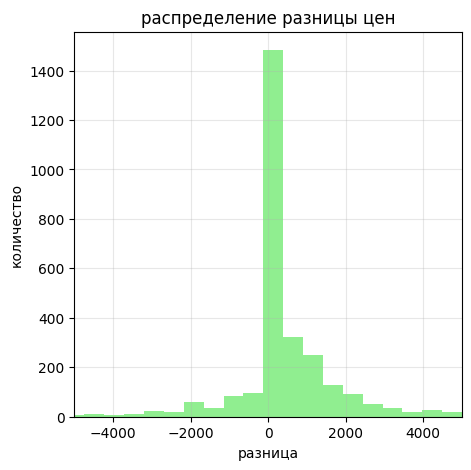

In [348]:
figure = plt.figure(figsize=(5,5))

plt.hist(both_platforms['price_diff'],color='lightgreen', bins = 100)
plt.title('распределение разницы цен')
plt.xlabel('разница')
plt.ylabel('количество')
plt.grid(alpha=0.3)
plt.xlim([-5000, 5000])
plt.show()

Критерии выбора:

1. Парные наблюдения — одни и те же врачи на двух платформах

2. Измерения зависимы — цена одного врача на двух платформах скоррелирована

3. Разница цен — количественная переменная

4. Распределение разницы —  ненормально

Используем тест Вилкоксона

In [349]:
res = stats.wilcoxon(both_platforms['price_sber'], both_platforms['price_prod'], alternative='greater', method='auto' )
print(f"p-value: {res.pvalue:.10f}")

p-value: 0.0000000000


In [350]:
diff = both_platforms['price_diff']
n = len(diff) - (diff == 0).sum()
z = res.statistic - (n*(n+1)/4)
z = z / np.sqrt(n*(n+1)*(2*n+1)/24)

effect = z / np.sqrt(len(both_platforms))
print(f'Z-статистика для Вилкоксона: {z:.3f}')
print(f'размер эффекта: {effect:.3f}')

Z-статистика для Вилкоксона: 15.789
размер эффекта: 0.294


Цены на СберЗдоровье статистически значимо выше, подтверждается z статистикой, но размер эффекта маленький < 0.3

оценим точность с помощью вычисления доверительного интервала с помощью бутстрапа

In [351]:
np.random.seed(42)
n_bootstrap = 10000
bootstrap_medians = []

for _ in range(n_bootstrap):
    sample = np.random.choice(diff, size=len(diff), replace=True)
    bootstrap_medians.append(np.median(sample))

ci_lower = np.percentile(bootstrap_medians, 2.5)
ci_upper = np.percentile(bootstrap_medians, 97.5)
median_diff = np.median(diff)

print(f'медианная разница цен: {median_diff:.0f}')
print(f'95% доверительный интервал для медианной разницы: от {ci_lower:.0f} до {ci_upper:.0f}')


медианная разница цен: 0
95% доверительный интервал для медианной разницы: от 0 до 0


в основном цены не различаются, тк более почти половина значений 0

посмотрим, что происходит если цены все таки разные

In [352]:
nonzero_diff = diff[diff != 0]

print(f'кол-во ненулевых разниц: {len(nonzero_diff)} из {len(diff)} {len(nonzero_diff)/len(diff)*100:.1f}%')
print(f'медиана ненулевых разниц: {np.median(nonzero_diff):.0f}')
print(f'среднее ненулевых разниц: {np.mean(nonzero_diff):.0f}')

np.random.seed(42)
bootstrap_nonzero_medians = []

for _ in range(10000):
    sample = np.random.choice(nonzero_diff, size=len(nonzero_diff), replace=True)
    bootstrap_nonzero_medians.append(np.median(sample))

ci_lower_nz = np.percentile(bootstrap_nonzero_medians, 2.5)
ci_upper_nz = np.percentile(bootstrap_nonzero_medians, 97.5)


print(f'медианная разница: {np.median(nonzero_diff):.0f}')
print(f'95% доверительный интервал: от {ci_lower_nz:.0f} до {ci_upper_nz:.0f}')

кол-во ненулевых разниц: 1581 из 2883 54.8%
медиана ненулевых разниц: 720
среднее ненулевых разниц: 593
медианная разница: 720
95% доверительный интервал: от 660 до 800


если разница все же есть, то 95% доверительный интервал: от 600 до 800

Тоесть если цена на одного врача отличается на разных платформах, то чаще на Сбере дороже

# 8.Влияние специальности на цену

H0: Средняя цена приема не зависит от специализации врача.

H1: Существуют статистически значимые различия в средней цене приема между разными специализациями.


In [353]:
specialties = ['гинеколог', 'кардиолог', 'невролог', 'онколог', 'терапевт', 'эндокринолог']
doctors1 = doctors.copy()

for specialty in specialties:
  if specialty == 'кардиолог':
    kardiolog = doctors1[doctors1['speciality'].str.contains(specialty,na=False)]
    kardiolog = kardiolog['price'].dropna()
    doctors1 = doctors1.drop(doctors1[doctors1['speciality'].str.contains(specialty,na=False)].index)
  if specialty == 'онколог':
    onkolog = doctors1[doctors1['speciality'].str.contains(specialty,na=False)]
    onkolog = onkolog['price'].dropna()
    doctors1 = doctors1.drop(doctors1[doctors1['speciality'].str.contains(specialty,na=False)].index)
  if specialty == 'эндокринолог':
    endokrinolog = doctors1[doctors1['speciality'].str.contains(specialty,na=False)]
    endokrinolog = endokrinolog['price'].dropna()
    doctors1 = doctors1.drop(doctors1[doctors1['speciality'].str.contains(specialty,na=False)].index)
  if specialty == 'невролог':
    nevrolog = doctors1[doctors1['speciality'].str.contains(specialty,na=False)]
    nevrolog = nevrolog['price'].dropna()
    doctors1 = doctors1.drop(doctors1[doctors1['speciality'].str.contains(specialty,na=False)].index)
  if specialty == 'терапевт':
    terapevt = doctors1[doctors1['speciality'].str.contains(specialty,na=False)]
    doctors1 = doctors1.drop(doctors1[doctors1['speciality'].str.contains(specialty,na=False)].index)
    terapevt = terapevt['price'].dropna()
  if specialty == 'гинеколог':
    ginekolog = doctors1[doctors1['speciality'].str.contains(specialty,na=False)]
    ginekolog = ginekolog['price'].dropna()
    doctors1 = doctors1.drop(doctors1[doctors1['speciality'].str.contains(specialty,na=False)].index)

In [354]:
print(len(ginekolog), len(kardiolog), len(nevrolog), len(onkolog), len(terapevt), len(endokrinolog))

2415 492 1234 547 1101 636


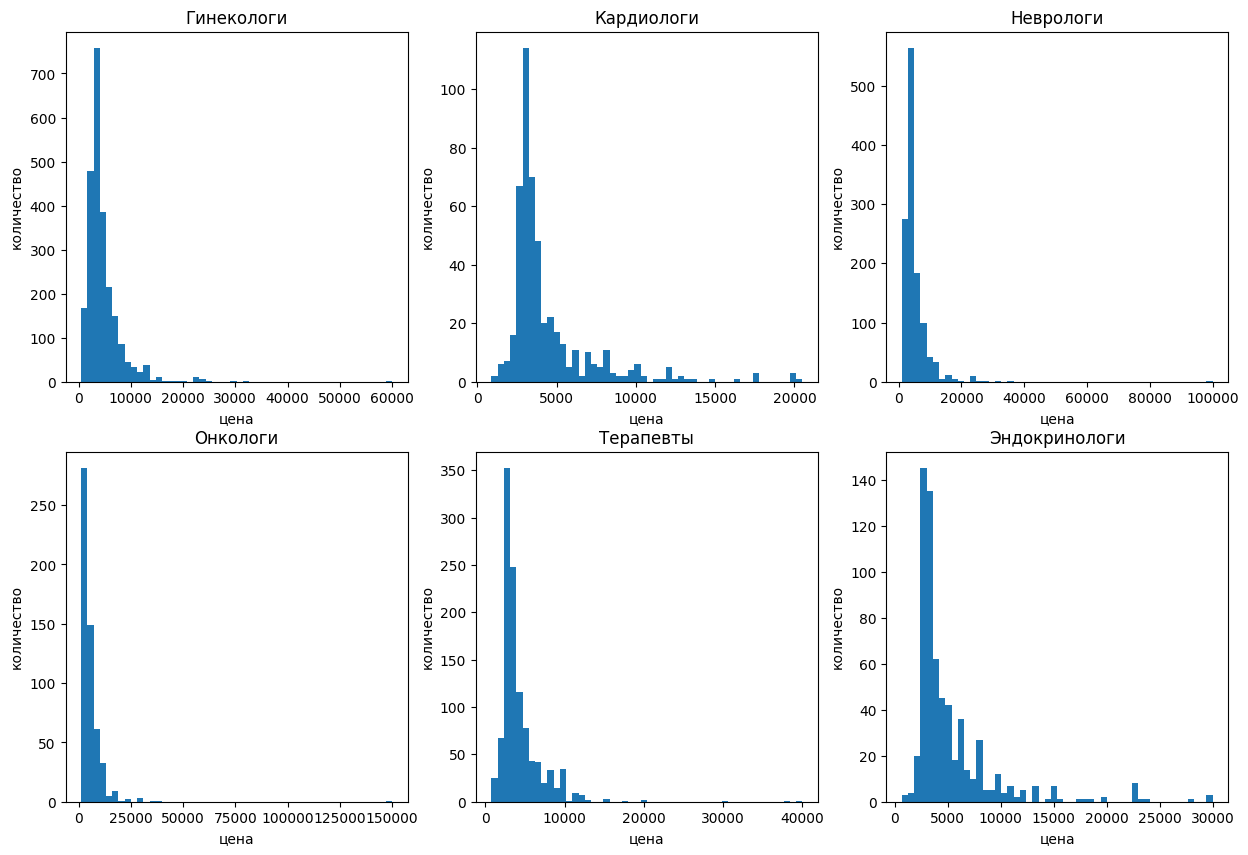

In [355]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].hist(ginekolog, bins=50)
axes[0,0].set_xlabel('цена')
axes[0,0].set_ylabel('количество')
axes[0,0].set_title('Гинекологи')

axes[0,1].hist(kardiolog, bins=50)
axes[0,1].set_xlabel('цена')
axes[0,1].set_ylabel('количество')
axes[0,1].set_title('Кардиологи')

axes[0,2].hist(nevrolog, bins=50)
axes[0,2].set_xlabel('цена')
axes[0,2].set_ylabel('количество')
axes[0,2].set_title('Неврологи')

axes[1,0].hist(onkolog, bins=50)
axes[1,0].set_xlabel('цена')
axes[1,0].set_ylabel('количество')
axes[1,0].set_title('Онкологи')

axes[1,1].hist(terapevt, bins=50)
axes[1,1].set_xlabel('цена')
axes[1,1].set_ylabel('количество')
axes[1,1].set_title('Терапевты')

axes[1,2].hist(endokrinolog, bins=50)
axes[1,2].set_xlabel('цена')
axes[1,2].set_ylabel('количество')
axes[1,2].set_title('Эндокринологи')

plt.show()

Распределения ненормальны, проверим дисперсии

In [356]:
data_groups = [ginekolog, kardiolog, nevrolog, onkolog, terapevt, endokrinolog]

levene_stat, levene_p = stats.levene(*data_groups, center='median')
print(f'p-value: {levene_p:.6f}')

p-value: 0.000000


p-value < 0.05 значит дисперсии неоднородны

Критерии выбора теста:

6 независимых групп

количественная переменная

данные не нормальны

разные размеры групп (от 255 до 1347)

неоднородность дисперсий

Используем тест Краскела-Уоллиса

In [357]:
result = stats.kruskal(*data_groups)

print(f"H-статистика: {result.statistic:.4f}")
print(f"p-value: {result.pvalue:.10f}")

H-статистика: 84.4976
p-value: 0.0000000000


p-value < 0.05 значит существуют статистически значимые различия в средней цене приема между разными специализациями

In [358]:
groups0 = {
    'гинеколог': ginekolog,
    'кардиолог': kardiolog,
    'невролог': nevrolog,
    'онколог': onkolog,
    'терапевт': terapevt,
    'эндокринолог': endokrinolog
}

In [359]:
for name, spec in groups0.items():
  print(f'{name}: средняя цена - {np.mean(spec)}, медианная цена - {np.median(spec)}')

гинеколог: средняя цена - 4604.517184265011, медианная цена - 3700.0
кардиолог: средняя цена - 4463.404471544715, медианная цена - 3500.0
невролог: средняя цена - 4990.3051053484605, медианная цена - 3675.0
онколог: средняя цена - 5896.363802559415, медианная цена - 4000.0
терапевт: средняя цена - 4327.509082652135, медианная цена - 3350.0
эндокринолог: средняя цена - 5236.525157232704, медианная цена - 3690.0


In [360]:
group_names = list(groups0.keys())
pairs = list(itertools.combinations(group_names, 2))

results = []
alpha = 0.05
k = len(pairs)  # number of comparisons

for name1, name2 in pairs:
    # Получаем данные по именам
    g1 = groups0[name1]
    g2 = groups0[name2]
    stat, p = mannwhitneyu(g1, g2, alternative="two-sided")

    results.append({
        "group1": name1,
        "group2": name2,
        "U_statistic": stat,
        "p_value_raw": p,
        "p_value_corrected": p * k, # Bonferroni correction
        "significant_after_correction": p * k < alpha
    })

posthoc_df = pd.DataFrame(results)
posthoc_df

,group1,group2,U_statistic,p_value_raw,p_value_corrected,significant_after_correction
0,гинеколог,кардиолог,607829.0,4.180369e-01,6.270554e+00,False
1,гинеколог,невролог,1394521.5,1.504019e-03,2.256029e-02,True
2,гинеколог,онколог,537840.0,1.095707e-11,1.643561e-10,True
3,гинеколог,терапевт,1384885.0,4.704292e-02,7.056438e-01,False
4,гинеколог,эндокринолог,708559.5,2.641966e-03,3.962949e-02,True
5,кардиолог,невролог,273739.0,1.413464e-03,2.120196e-02,True
6,кардиолог,онколог,102942.0,5.774149e-11,8.661224e-10,True
7,кардиолог,терапевт,276990.5,4.687622e-01,7.031433e+00,False
8,кардиолог,эндокринолог,140467.5,3.199708e-03,4.799563e-02,True
9,невролог,онколог,292141.0,5.846151e-06,8.769227e-05,True


Онколог - отличается от всех других групп и имеет аксимальные статистические различия, однако для всех |размер эффекта| < 0.3, тоесть незначительный

##Средняя цена приема врачей-онкологов статистически значимо выше, чем средняя цена по другим специальностям

In [361]:
data_groups_2 = {'ginekolog': ginekolog, 'kardiolog':kardiolog, 'nevrolog':nevrolog, 'terapevt':terapevt, 'endokrinolog':endokrinolog}

In [362]:
other_specialties = pd.concat([ginekolog, kardiolog, nevrolog, terapevt, endokrinolog])
res = stats.mannwhitneyu(onkolog, other_specialties,
                      alternative='greater',
                      method='auto')
print(f'p-value онкологи с остальными: {res.pvalue:.10f}')

for name, spec in data_groups_2.items():
  stat, p_value = stats.mannwhitneyu(onkolog, spec,
                      alternative='greater',
                      method='auto')
  # Эффект размера r = Z / sqrt(N)
  n1, n2 = len(onkolog), len(spec)
  mean_U = n1 * n2 / 2
  std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
  z = (stat - mean_U) / std_U
  r = z / np.sqrt(n1 + n2)

  print(f'p-value онкологи с {name}: {p_value:.10f}, r: {r}')




p-value онкологи с остальными: 0.0000000000
p-value онкологи с ginekolog: 0.0000000000, r: 0.12479346726545805
p-value онкологи с kardiolog: 0.0000000000, r: 0.203119599075784
p-value онкологи с nevrolog: 0.0000029231, r: 0.10735133932480596
p-value онкологи с terapevt: 0.0000000000, r: 0.20496046003597543
p-value онкологи с endokrinolog: 0.0001171539, r: 0.10691945973829499


p-value < 0.05 значит существуют статистически значимые различия в средней цене онкологов и остальными

#9.Влияние специальности на рейтинг.


H0: Средний рейтинг врача не зависит от его специализации.

H1: Существуют статистически значимые различия в среднем рейтинге между разными специализациями.

In [363]:
specialties = ['хирург','гинеколог', 'кардиолог', 'невролог', 'онколог', 'терапевт', 'эндокринолог']
doctors2 = doctors.copy()

for specialty in specialties:
  if specialty == 'хирург':
    hirurg = doctors2[doctors2['speciality'].str.contains(specialty,na=False)]
    hirurg = hirurg[hirurg['is_kids']==True]
    hirurg = hirurg['rating'].dropna()
    doctors2 = doctors2.drop(doctors2[doctors2['speciality'].str.contains(specialty,na=False)].index)
  if specialty == 'кардиолог':
    kardiolog = doctors2[doctors2['speciality'].str.contains(specialty,na=False)]
    kardiolog = kardiolog['rating'].dropna()
    doctors2 = doctors2.drop(doctors2[doctors2['speciality'].str.contains(specialty,na=False)].index)
  if specialty == 'онколог':
    onkolog = doctors2[doctors2['speciality'].str.contains(specialty,na=False)]
    onkolog = onkolog['rating'].dropna()
    doctors2 = doctors2.drop(doctors2[doctors2['speciality'].str.contains(specialty,na=False)].index)
  if specialty == 'эндокринолог':
    endokrinolog = doctors2[doctors2['speciality'].str.contains(specialty,na=False)]
    endokrinolog = endokrinolog['rating'].dropna()
    doctors2 = doctors2.drop(doctors2[doctors2['speciality'].str.contains(specialty,na=False)].index)
  if specialty == 'невролог':
    nevrolog = doctors2[doctors2['speciality'].str.contains(specialty,na=False)]
    nevrolog = nevrolog['rating'].dropna()
    doctors2 = doctors2.drop(doctors2[doctors2['speciality'].str.contains(specialty,na=False)].index)
  if specialty == 'терапевт':
    terapevt = doctors2[doctors2['speciality'].str.contains(specialty,na=False)]
    doctors2 = doctors2.drop(doctors2[doctors2['speciality'].str.contains(specialty,na=False)].index)
    terapevt = terapevt['rating'].dropna()
  if specialty == 'гинеколог':
    ginekolog = doctors2[doctors2['speciality'].str.contains(specialty,na=False)]
    ginekolog = ginekolog['rating'].dropna()
    doctors2 = doctors2.drop(doctors2[doctors2['speciality'].str.contains(specialty,na=False)].index)

In [364]:
print(len(hirurg), len(ginekolog), len(kardiolog), len(nevrolog), len(onkolog), len(terapevt), len(endokrinolog))

66 5265 2435 4130 1689 6643 1947


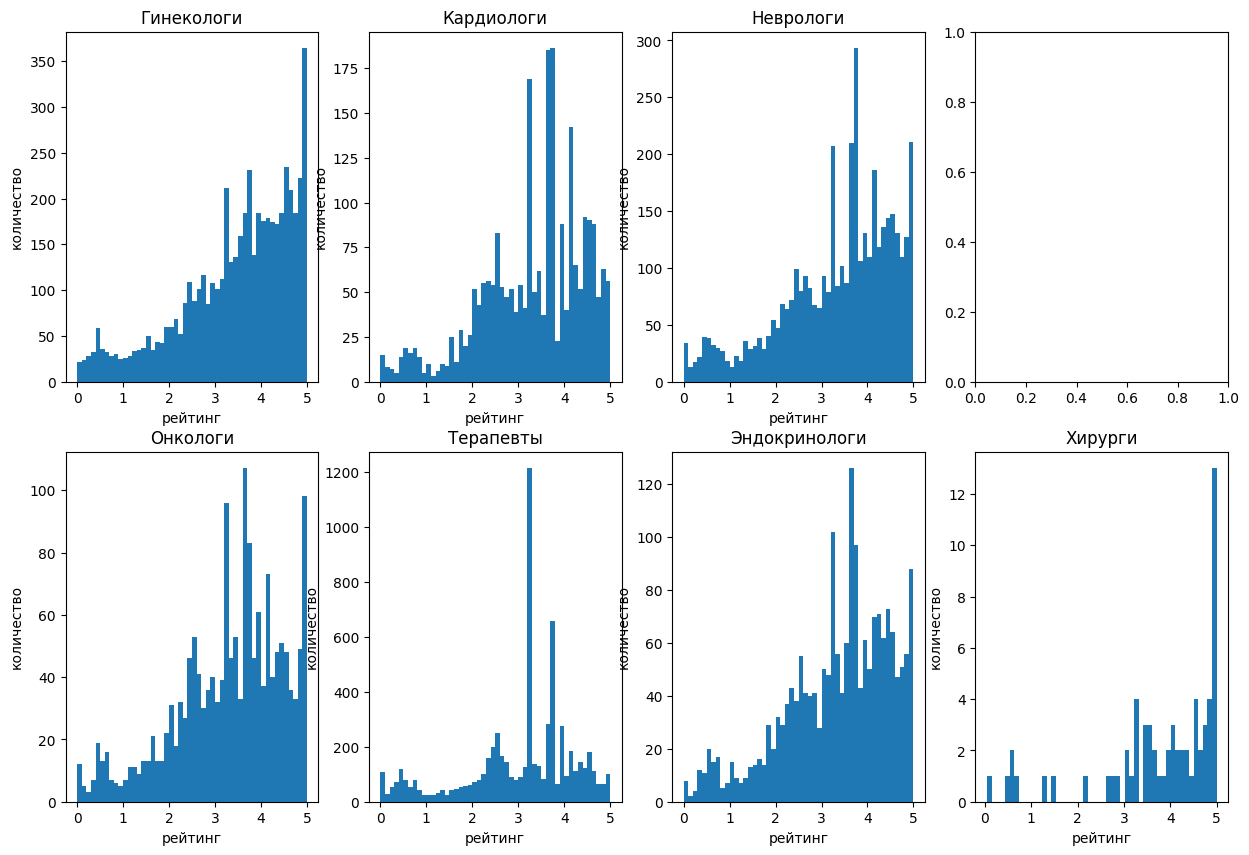

In [365]:
fig, axes = plt.subplots(2, 4, figsize=(15, 10))

axes[0,0].hist(ginekolog, bins=50)
axes[0,0].set_xlabel('рейтинг')
axes[0,0].set_ylabel('количество')
axes[0,0].set_title('Гинекологи')

axes[0,1].hist(kardiolog, bins=50)
axes[0,1].set_xlabel('рейтинг')
axes[0,1].set_ylabel('количество')
axes[0,1].set_title('Кардиологи')

axes[0,2].hist(nevrolog, bins=50)
axes[0,2].set_xlabel('рейтинг')
axes[0,2].set_ylabel('количество')
axes[0,2].set_title('Неврологи')

axes[1,0].hist(onkolog, bins=50)
axes[1,0].set_xlabel('рейтинг')
axes[1,0].set_ylabel('количество')
axes[1,0].set_title('Онкологи')

axes[1,1].hist(terapevt, bins=50)
axes[1,1].set_xlabel('рейтинг')
axes[1,1].set_ylabel('количество')
axes[1,1].set_title('Терапевты')

axes[1,2].hist(endokrinolog, bins=50)
axes[1,2].set_xlabel('рейтинг')
axes[1,2].set_ylabel('количество')
axes[1,2].set_title('Эндокринологи')

axes[1,3].hist(hirurg, bins=50)
axes[1,3].set_xlabel('рейтинг')
axes[1,3].set_ylabel('количество')
axes[1,3].set_title('Хирурги')

plt.show()

Распределения ненормальны, проверим дисперсии

In [366]:
groups = {
    'хирург': hirurg,
    'гинеколог': ginekolog,
    'кардиолог': kardiolog,
    'невролог': nevrolog,
    'онколог': onkolog,
    'терапевт': terapevt,
    'эндокринолог': endokrinolog
}

In [367]:
data_groups = [hirurg, ginekolog, kardiolog, nevrolog, onkolog, terapevt, endokrinolog]

levene_stat, levene_p = stats.levene(*data_groups, center='median')
print(f'p-value: {levene_p:.6f}')

p-value: 0.000000


p-value < 0.05 значит дисперсии неоднородны

**Критерии выбора теста:**

7 независимых групп

количественная переменная

данные не нормальны

разные размеры групп

неоднородность дисперсий

Используем тест Краскела-Уоллиса

In [368]:
result = stats.kruskal(*data_groups)

print(f"H-статистика: {result.statistic:.4f}")
print(f"p-value: {result.pvalue:.10f}")

H-статистика: 545.3612
p-value: 0.0000000000


p-value < 0.05 значит существуют статистически значимые различия в среднем рейтинге между разными специализациями

In [369]:
group_names = list(groups.keys())
pairs = list(itertools.combinations(group_names, 2))

results = []
alpha = 0.05
k = len(pairs)  # number of comparisons

for name1, name2 in pairs:
    # Получаем данные по именам
    g1 = groups[name1]
    g2 = groups[name2]
    stat, p = mannwhitneyu(g1, g2, alternative="two-sided")

    # Эффект размера r = Z / sqrt(N)
    n1, n2 = len(g1), len(g2)
    mean_U = n1 * n2 / 2
    std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z = (stat - mean_U) / std_U
    r = z / np.sqrt(n1 + n2)

    results.append({
        "group1": name1,
        "group2": name2,
        "U_statistic": stat,
        "p_value_raw": p,
        "p_value_corrected": p * k, # Bonferroni correction
        "significant_after_correction": p * k < alpha,
        "effect_size": r
    })

posthoc_df = pd.DataFrame(results)
posthoc_df

,group1,group2,U_statistic,p_value_raw,p_value_corrected,significant_after_correction,effect_size
0,хирург,гинеколог,210053.5,3.477741e-03,7.303257e-02,False,0.040020
1,хирург,кардиолог,105221.5,1.730972e-05,3.635041e-04,True,0.085898
2,хирург,невролог,172245.0,2.307830e-04,4.846443e-03,True,0.056848
3,хирург,онколог,72228.5,4.438170e-05,9.320156e-04,True,0.097468
4,хирург,терапевт,313705.5,1.440988e-09,3.026075e-08,True,0.073674
5,хирург,эндокринолог,82545.5,8.165751e-05,1.714808e-03,True,0.087802
6,гинеколог,кардиолог,7046760.5,2.236575e-12,4.696807e-11,True,0.079984
7,гинеколог,невролог,11510501.5,9.993180e-07,2.098568e-05,True,0.050467
8,гинеколог,онколог,4857403.5,1.024794e-08,2.152067e-07,True,0.068670
9,гинеколог,терапевт,21497448.5,7.177309e-103,1.507235e-101,True,0.197228


In [370]:
for name, spec in groups.items():
  print(f'{name}: средний рейтинг - {np.mean(spec)}, медианный рейтинг - {np.median(spec)}')

хирург: средний рейтинг - 3.7835704308130578, медианный рейтинг - 4.103382221832032
гинеколог: средний рейтинг - 3.451443632488134, медианный рейтинг - 3.712984643966733
кардиолог: средний рейтинг - 3.3209803437371526, медианный рейтинг - 3.5948947637346014
невролог: средний рейтинг - 3.3520216709353217, медианный рейтинг - 3.6000000000000005
онколог: средний рейтинг - 3.306882579566208, медианный рейтинг - 3.5
терапевт: средний рейтинг - 3.0404999194853164, медианный рейтинг - 3.25
эндокринолог: средний рейтинг - 3.3404620186747422, медианный рейтинг - 3.5847118426343205


In [371]:
data_groups4 = {'гинеколог': ginekolog,'onkolog': onkolog, 'kardiolog':kardiolog, 'nevrolog':nevrolog, 'terapevt':terapevt, 'endokrinolog':endokrinolog}

In [372]:
other_specialties4 = pd.concat([ginekolog, onkolog, kardiolog, nevrolog, terapevt, endokrinolog])
res = stats.mannwhitneyu(hirurg, other_specialties4,
                      alternative='greater',
                      method='auto')
print(f'p-value хирургов с остальными: {res.pvalue:.10f}')

for name, spec in data_groups4.items():
  res = stats.mannwhitneyu(hirurg, spec,
                      alternative='greater',
                      method='auto')
  print(f'p-value хирургов с {name}: {res.pvalue:.10f}')

p-value хирургов с остальными: 0.0000064737
p-value хирургов с гинеколог: 0.0017388706
p-value хирургов с onkolog: 0.0000221908
p-value хирургов с kardiolog: 0.0000086549
p-value хирургов с nevrolog: 0.0001153915
p-value хирургов с terapevt: 0.0000000007
p-value хирургов с endokrinolog: 0.0000408288


Детские хирурги действительно выше все показатели и. это различия статистически значимы

Вторыми по величине были гинекологи, проверим их

In [373]:
data_groups3 = {'onkolog': onkolog, 'kardiolog':kardiolog, 'nevrolog':nevrolog, 'terapevt':terapevt, 'endokrinolog':endokrinolog}

In [374]:
other_specialties = pd.concat([onkolog, kardiolog, nevrolog, terapevt, endokrinolog])
res = stats.mannwhitneyu(ginekolog, other_specialties,
                      alternative='greater',
                      method='auto')
print(f'p-value гинекологов с остальными: {res.pvalue:.10f}')

for name, spec in data_groups3.items():
  res = stats.mannwhitneyu(ginekolog, spec,
                      alternative='greater',
                      method='auto')
  print(f'p-value гинекологов с {name}: {res.pvalue:.10f}')

p-value гинекологов с остальными: 0.0000000000
p-value гинекологов с onkolog: 0.0000000051
p-value гинекологов с kardiolog: 0.0000000000
p-value гинекологов с nevrolog: 0.0000004997
p-value гинекологов с terapevt: 0.0000000000
p-value гинекологов с endokrinolog: 0.0000001247


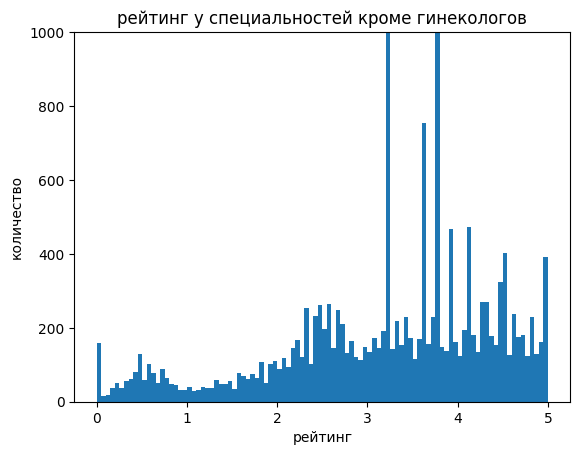

In [375]:
plt.hist(other_specialties, bins = 100)
plt.title('рейтинг у специальностей кроме гинекологов')
plt.xlabel('рейтинг')
plt.ylabel('количество')
plt.ylim((0,1000))
plt.show()

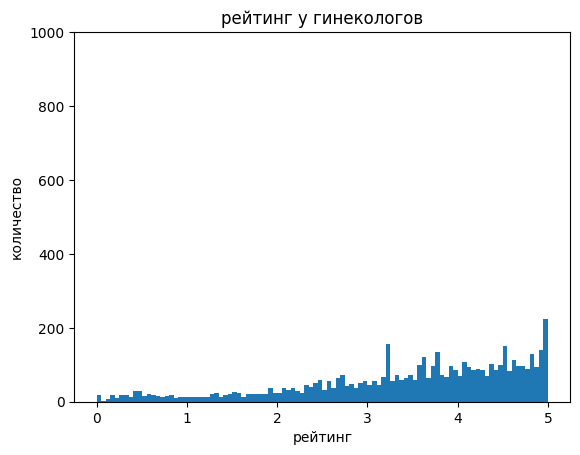

In [376]:
plt.hist(ginekolog, bins = 100)
plt.title('рейтинг у гинекологов')
plt.xlabel('рейтинг')
plt.ylabel('количество')
plt.ylim((0,1000))
plt.show()

Получаем, что гинекологи у которых статистики больше, отличаются от остальных специальностей

Проверим терапевтов со всеми, тк они отличаются от всех

In [377]:
data_groups4 = {'onkolog': onkolog, 'kardiolog':kardiolog, 'nevrolog':nevrolog, 'ginekolog': ginekolog, 'endokrinolog':endokrinolog}

In [378]:
other_specialties = pd.concat([onkolog, kardiolog, nevrolog, ginekolog, endokrinolog])
res = stats.mannwhitneyu(terapevt, other_specialties,
                      alternative='greater',
                      method='auto')
print(f'p-value terapevt с остальными: {res.pvalue:.10f}')

for name, spec in data_groups4.items():
  stat, p_value = stats.mannwhitneyu(terapevt, spec,
                      alternative='less',
                      method='auto')

  # Эффект размера r = Z / sqrt(N)
  n1, n2 = len(terapevt), len(spec)
  mean_U = n1 * n2 / 2
  std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
  z = (stat - mean_U) / std_U
  r = z / np.sqrt(n1 + n2)
  print(f'p-value terapevt с {name}: {p_value:.10f}, r:{r}')

p-value terapevt с остальными: 1.0000000000
p-value terapevt с onkolog: 0.0000000000, r:-0.09490777097088467
p-value terapevt с kardiolog: 0.0000000000, r:-0.10720823949730073
p-value terapevt с nevrolog: 0.0000000000, r:-0.14723229083173547
p-value terapevt с ginekolog: 0.0000000000, r:-0.19722849139033125
p-value terapevt с endokrinolog: 0.0000000000, r:-0.11131871692023006


терапевты имеет рейтинг ниже всех

#10.Цена приема у детских врачей выше.


H0: Средняя цена приема у врачей детских специальностей не отичается от средней цены приема у врачей "взрослых" специальностей.

H1: Средняя цена приема у врачей детских специальностей статистически значимо выше, чем у врачей "взрослых" специальностей.

In [379]:
kids = doctors[(doctors['is_kids']==True)&(doctors['is_adults']==False)]
kids = kids['price'].dropna()

adults= doctors[(doctors['is_kids']==False)&(doctors['is_adults']==True)]
adults = adults['price'].dropna()

In [380]:
print(len(kids), len(adults))

126 6292


In [381]:
kids.describe()

,price
count,126.000000
mean,4974.273810
std,3335.541064
min,1500.000000
25%,2922.500000
50%,3500.000000
75%,6675.000000
max,23694.000000


In [382]:
adults.describe()

,price
count,6292.000000
mean,4804.754291
std,3963.342263
min,500.000000
25%,2918.750000
50%,3600.000000
75%,5500.000000
max,150000.000000


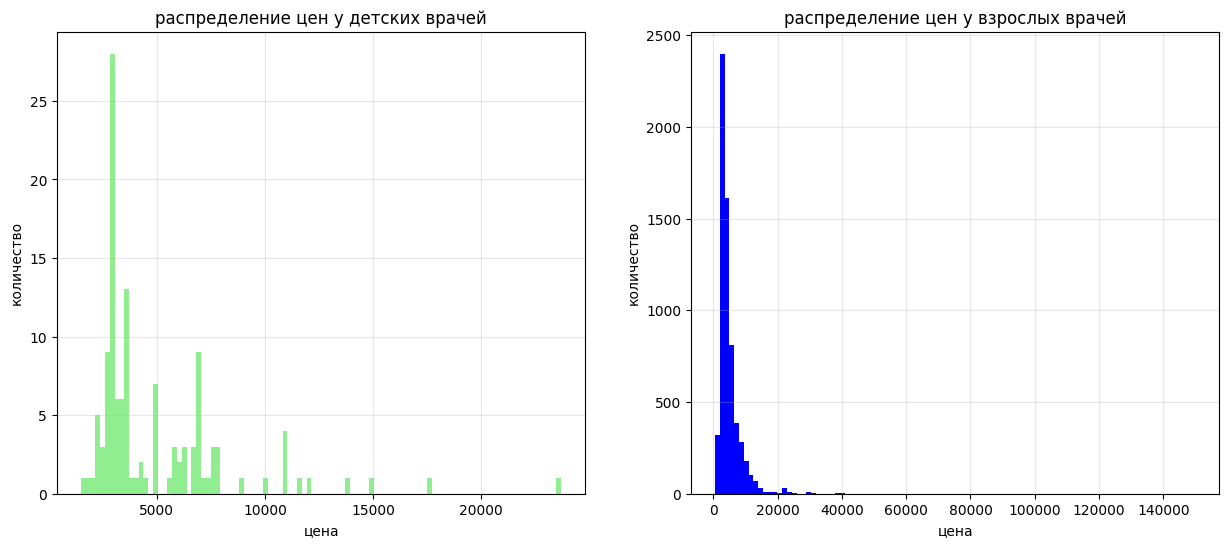

In [383]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(kids,color='lightgreen', bins = 100)
axes[0].set_title('распределение цен у детских врачей')
axes[0].set_xlabel('цена')
axes[0].set_ylabel('количество')
axes[0].grid(alpha=0.3)

axes[1].hist(adults,color='blue', bins = 100)
axes[1].set_title('распределение цен у взрослых врачей')
axes[1].set_xlabel('цена')
axes[1].set_ylabel('количество')
axes[1].grid(alpha=0.3)

In [384]:
levene_stat, levene_p = stats.levene(kids, adults)
print(f"p-value = {levene_p:.6f}")

p-value = 0.726090


Дисперсии однородны

In [385]:
result = stats.mannwhitneyu(kids, adults,alternative='two-sided',method='auto')
print(f"p-value: {result.pvalue:.10f}")

p-value: 0.7904924430


Не можем опровергнуть нулевую гипотезу, нет статистически значимых различий между детскими и взрослыми врачами